## Client Portfolio

Client Portfolio Value Tracker (lean version)

Asks the client only what's needed to value the portfolio right now: stock holdings (fetched at live market price) plus the current value of Treasury Bills, Mutual Funds, and Cash. No return/risk assumptions needed.

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
def naira(amount):
    return f"₦{amount:,.2f}"

In [3]:
def get_stock_holdings():
    holdings = []
    n = int(input("How many different stocks does the client hold? "))
    for i in range(n):
        print(f"\n Stock {i + 1} ")
        ticker = input("Ticker symbol (e.g. AAPL, DANGCEM.LG): ").strip().upper()
        shares = float(input(f"Number of shares held in {ticker}: "))

        try:
            price = float(yf.Ticker(ticker).history(period="1d")["Close"].iloc[-1])
        except Exception:
            print(f"Could not fetch a live price for {ticker}; enter it manually.")
            price = float(input(f"Manual current price for {ticker}: "))

        market_value = shares * price
        holdings.append({"ticker": ticker, "shares": shares, "price": price,
                          "market_value": market_value})
        print(f"{ticker}: {shares} shares @ {naira(price)} = {naira(market_value)}")

    return holdings

In [4]:
def collect_client_inputs():
    print(" Client Portfolio Value Intake \n")
    name = input("Investor Name: ").strip()

    stock_holdings = get_stock_holdings()
    stock_value = sum(h["market_value"] for h in stock_holdings)

    print("\n Other Holdings ")
    tbill_value = float(input("Treasury Bills current value (₦): "))
    mf_value = float(input("Mutual Funds current value (₦): "))
    cash_value = float(input("Cash (₦): "))

    return { "name": name, "stock_holdings": stock_holdings,
        "values": { "Stocks": stock_value, "Treasury Bills": tbill_value, "Mutual Funds": mf_value,  "Cash": cash_value,}, }

In [5]:
def analyze_portfolio(data):
    values = data["values"]
    total_value = sum(values.values())
    weights = {k: v / total_value for k, v in values.items()}
    return {"total_value": total_value, "weights": weights}

In [6]:
def build_summary_sentence(data, results):
    w = results["weights"]
    allocation_text = ", ".join(f"{k} {w[k]*100:.1f}%" for k in w)
    return ( f"Dear {data['name']}, your investment portfolio is currently valued at " 
             f"{naira(results['total_value'])}, allocated across {allocation_text}." )


In [7]:
def print_breakdown(data, results):
    print("\n Portfolio Breakdown ")
    for asset, value in data["values"].items():
        pct = results["weights"][asset] * 100
        print(f"{asset:<16} {naira(value):>18}  ({pct:.1f}%)")
    print(f"{'Total':<16} {naira(results['total_value']):>18}")

    if data["stock_holdings"]:
        print("\n Stock Positions (live price) ")
        for h in data["stock_holdings"]:
            print(f"{h['ticker']:<10} {h['shares']:>10.2f} sh "
                  f"@ {naira(h['price'])}  = {naira(h['market_value'])}")

 Client Portfolio Value Intake 



Investor Name:  ebere
How many different stocks does the client hold?  2



 Stock 1 


Ticker symbol (e.g. AAPL, DANGCEM.LG):  aapl
Number of shares held in AAPL:  30


AAPL: 30.0 shares @ ₦321.66 = ₦9,649.80

 Stock 2 


Ticker symbol (e.g. AAPL, DANGCEM.LG):  meta
Number of shares held in META:  10


META: 10.0 shares @ ₦606.10 = ₦6,061.00

 Other Holdings 


Treasury Bills current value (₦):  10000
Mutual Funds current value (₦):  2000
Cash (₦):  23



 Portfolio Breakdown 
Stocks                   ₦15,710.80  (56.6%)
Treasury Bills           ₦10,000.00  (36.1%)
Mutual Funds              ₦2,000.00  (7.2%)
Cash                         ₦23.00  (0.1%)
Total                    ₦27,733.80

 Stock Positions (live price) 
AAPL            30.00 sh @ ₦321.66  = ₦9,649.80
META            10.00 sh @ ₦606.10  = ₦6,061.00

 Client Summary 
Dear ebere, your investment portfolio is currently valued at ₦27,733.80, allocated across Stocks 56.6%, Treasury Bills 36.1%, Mutual Funds 7.2%, Cash 0.1%.


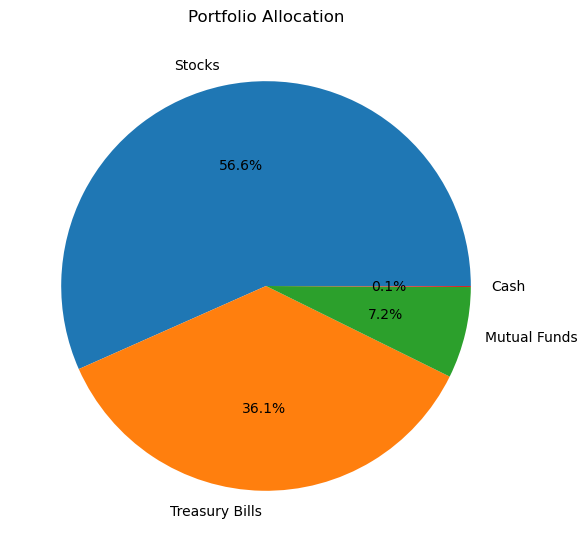

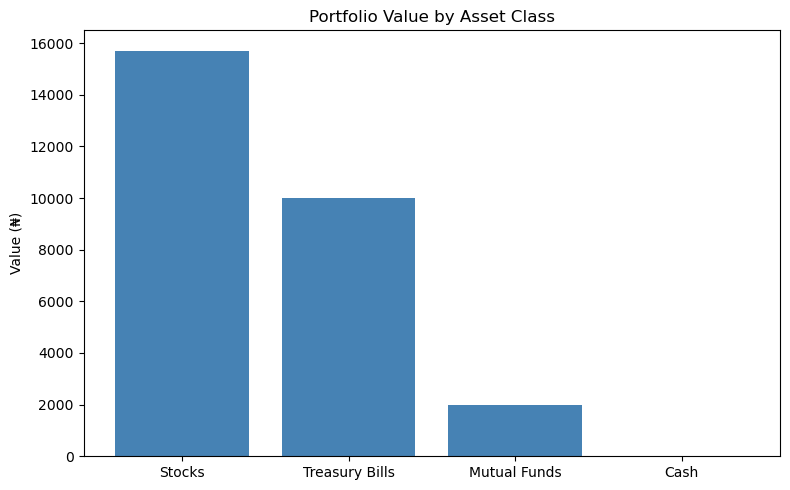

In [8]:
def plot_allocation(results):
    weights = results["weights"]
    plt.figure(figsize=(6, 6))
    plt.pie(weights.values(), labels=weights.keys(), autopct="%1.1f%%")
    plt.title("Portfolio Allocation")
    plt.tight_layout()
    plt.show()

def plot_value_by_asset(data):
    values = data["values"]
    plt.figure(figsize=(8, 5))
    plt.bar(values.keys(), values.values(), color="steelblue")
    plt.ylabel("Value (₦)")
    plt.title("Portfolio Value by Asset Class")
    plt.tight_layout()
    plt.show()

def main():
    data = collect_client_inputs()
    results = analyze_portfolio(data)
    print_breakdown(data, results)
    print("\n Client Summary ")
    print(build_summary_sentence(data, results))

    plot_allocation(results)
    plot_value_by_asset(data)


if __name__ == "__main__":
    main()

Create a code that will convert the prices of shares to naira since these stocks are priced in USD. 